In [5]:
import os
MAIN_DIR='/home/jovyan/code4'
os.chdir(MAIN_DIR)
print(os.getcwd())

/home/jovyan/code4


In [35]:
import numpy as np
import json
import pickle
import random
from tqdm import tqdm
import torch
import os
from pathlib import Path as Data_Path
import networkx as nx
from graph_building_routines import graph_attribute_builder 
from spotify_data_loader import spotify_data_loader
from basic_types import JSONFile
from graph_analyzer import *
import matplotlib.pyplot as plt
import matplotlib
plt.rcParams.update({ "text.usetex": True, "font.family": "serif" })
font = {'size': 16}
matplotlib.rc('font', **font)
fmt = 'pdf'

In [41]:
def dist_fitter(dist, edges, clip):
    indskp = dist > 0.
    yvals = np.log(dist[indskp])
    xvals = np.log(edges[:-1][indskp])
    indskp = xvals < clip
    if len(xvals[indskp]) < 2:
        raise ValueError("Not enough data points after clipping for polyfit.")
    coefficients = np.polyfit(xvals[indskp], yvals[indskp], 1)
    power = coefficients[0]
    cval = coefficients[1]
    return (power, cval, indskp)

In [8]:
def playlist_track_JSON_loader(JSONs):
  playlist_data = {}
  playlists = []
  tracks = []
  artists = []
  playlist_track_edges = []
  track_artist_edges = []
  # build list of all unique playlists, tracks, and artists 
  for json_file in tqdm(JSONs):
    playlists += [p.name for p in json_file.playlists.values()]
    tracks += [track.uri for playlist in json_file.playlists.values() for track in list(playlist.tracks.values())]
    artists += [track.artist_uri for playlist in json_file.playlists.values() for track in list(playlist.tracks.values())]
    
    playlist_track_edges += [(playlist.name, track.uri) for playlist in json_file.playlists.values() for track in list(playlist.tracks.values())]
    track_artist_edges += [(track.uri, track.artist_uri) for playlist in json_file.playlists.values() for track in list(playlist.tracks.values())]

    playlist_data = playlist_data | json_file.playlists
  return playlists, tracks, artists, playlist_track_edges, track_artist_edges, playlist_data


In [21]:
DATA_PATH = Data_Path('/home/jovyan/Updated_code/data')
file_names_to_use = sorted([f for f in os.listdir(DATA_PATH) 
                            if os.path.isfile(os.path.join(DATA_PATH, f)) and f.endswith('.json')])

seed = 224
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)


n_playlists = 0

# load each json file, and store it in a list of files
JSONs = []
for file_name in tqdm(file_names_to_use, desc='Files processed: ', unit='files', total=len(file_names_to_use)):
  json_file = JSONFile(DATA_PATH, file_name, n_playlists)
  json_file.process_file()
  n_playlists += len(json_file.playlists)
  JSONs.append(json_file)

playlists, tracks, artists, playlist_track, track_artist, playlist_data = playlist_track_JSON_loader(JSONs)

N_FILES_TO_USE=30

100%|██████████| 31/31 [00:00<00:00, 37.91it/s]


In [22]:
Gred = pickle.load(open(f"{30}core_first_{30}.pkl", "rb"))

kcore_selected_artist = [x for x,y in Gred.nodes(data=True) if y["node_type"]=="artist"]
kcore_selected_playlists = [x for x,y in Gred.nodes(data=True) if y["node_type"]=="playlist"]
kcore_selected_tracks = [x for x,y in Gred.nodes(data=True) if y["node_type"]=="track"]
num_playlists = len(kcore_selected_playlists)
num_tracks = len(kcore_selected_tracks)
num_artist = len(kcore_selected_artist)
print(f"Number of kcore selected playlists: {num_playlists}")
print(f"Number of kcore selected tracks: {num_tracks}")
print(f"NUmber of kcore slected artists: {num_artist}")

Number of kcore selected playlists: 12322
Number of kcore selected tracks: 7669
NUmber of kcore slected artists: 0


In [23]:
def extra_attribute_edge_index(kcore_selected_tracks, track_artist, num_playlists, num_tracks):
    kcore_track_artist = []
    kcore_selected_artists = []
    for x, y in track_artist:
        if x in kcore_selected_tracks:
            kcore_track_artist.append((x, y))
            if y not in kcore_selected_artists:
                kcore_selected_artists.append(y)

    kcore_reduced_track_artist_graph = graph_attribute_builder(kcore_selected_tracks, 'track', kcore_selected_artists, 'artist', kcore_track_artist)
    return kcore_reduced_track_artist_graph

In [26]:
G_AT= extra_attribute_edge_index(kcore_selected_tracks, track_artist, num_playlists, num_tracks)

In [27]:
kcore_selected_artist = [x for x,y in G_AT.nodes(data=True) if y["node_type"]=="artist"]
num_artist = len(kcore_selected_artist)
print(f"NUmber of kcore slected artists: {num_artist}")
print(f"Number of nodes: {G_AT.number_of_nodes()}")

NUmber of kcore slected artists: 2119
Number of nodes: 9788


In [28]:
print(nx.is_bipartite(G_AT))
print(G_AT.number_of_nodes())
print(G_AT.number_of_edges())

True
9788
7669


In [29]:
deg_seq = degree_sequence(G_AT)

[-1.7020553786377857, -2.0440405017529164]
[-1.7020553786377857, -2.0440405017529164]


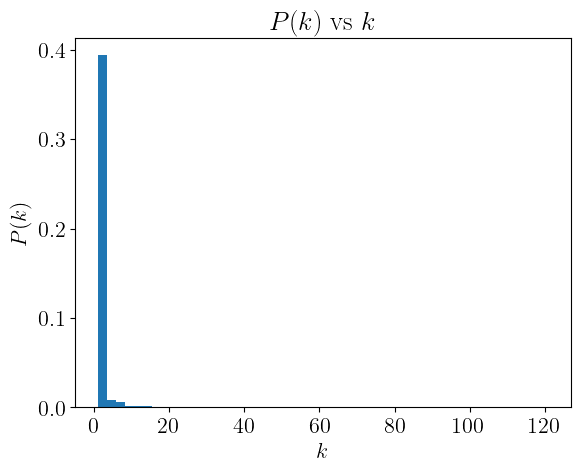

In [36]:
nbins = 50
dist, edges = plt_deg_distribution(deg_seq, nbins)
plt.savefig("full_hist.pdf", dpi=150, bbox_inches='tight')  
etrim = edges[:-1]
powerfull, cvalfull, indskpfull = dist_fitter(dist, edges, 8.)
powertrunc, cvaltrunc, indskptrunc = dist_fitter(dist, edges, 6.)
print([cvalfull, powerfull])
print([cvaltrunc, powertrunc])

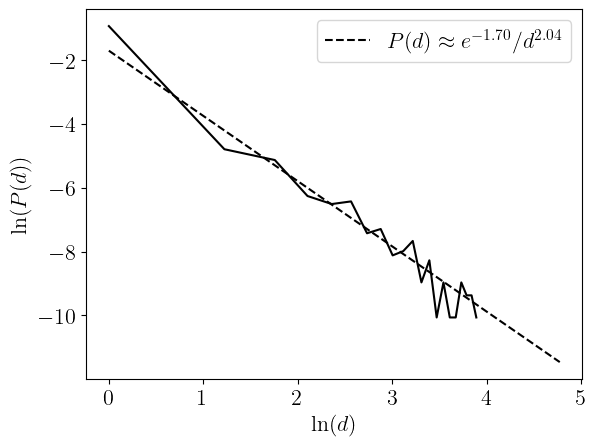

In [37]:
plt.plot(np.log(etrim), np.ma.log(dist),color='k')
scvalfull = "{:1.2f}".format(cvalfull)
spowerfull = "{:1.2f}".format(-powerfull)
scvaltrunc = "{:1.2f}".format(cvaltrunc)
spowertrunc = "{:1.2f}".format(-powertrunc)

plt.plot(np.log(etrim), np.log(np.exp(cvalfull) * (etrim)**powerfull), color='k', ls='--', label = r"$P(d)\approx e^{"+scvalfull+"}/d^{"+spowerfull+"}$")
#plt.plot(np.log(etrim), np.log(np.exp(cvaltrunc) * (etrim)**powertrunc), color='r', ls='--', label = r"$P(d)\approx e^{"+scvaltrunc+"}/d^{"+spowertrunc+"}$")
plt.xlabel(r"$\ln(d)$")
plt.ylabel(r"$\ln(P(d))$")
plt.legend()
plt.savefig("total_degree_dist_fit.pdf", dpi=150, bbox_inches='tight')  

In [39]:
from networkx.algorithms import bipartite

bmat = bipartite.biadjacency_matrix(G_AT, row_order=kcore_selected_tracks, column_order=set(kcore_selected_artist), dtype=np.float64)
d1 = np.sum(bmat, axis=1) #degrees of tracks
d2 = np.sum(bmat, axis=0) #degrees of artists
degrees = np.concatenate((d1, d2))

In [ ]:
nbins = 100
dist, edges = plt_deg_distribution(d1, nbins)
indskp = dist > 0.
yvals = np.log(dist[indskp])
xvals = np.log(edges[:-1][indskp])

ValueError: Not enough data points after clipping for polyfit.

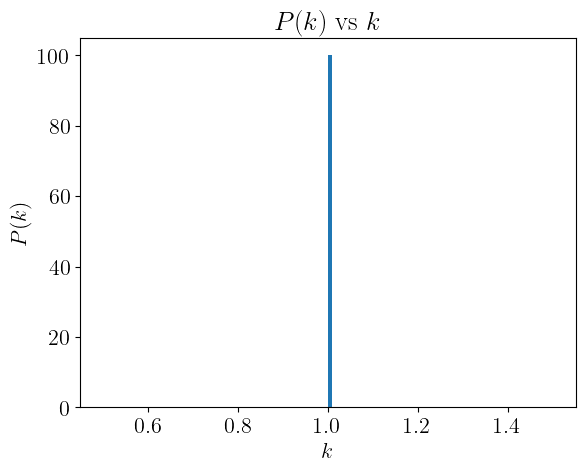

In [42]:
nbins = 100
dist, edges = plt_deg_distribution(d1, nbins)
plt.savefig("t_hist.pdf", dpi=150, bbox_inches='tight')  
etrim = edges[:-1]
powerfull, cvalfull, indskpfull = dist_fitter(dist, edges, 8.)
powertrunc, cvaltrunc, indskptrunc = dist_fitter(dist, edges, 5.)
print([cvalfull, powerfull])
print([cvaltrunc, powertrunc])